# Porównanie modeli predykcji BTC
Wczytuje wyniki z `models/training_report.json` i wygenerowane modele.
Uruchom najpierw: `python src/run_all.py`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from config      import MODELS_DIR, HORIZONS
from data_loader import load_full, make_sequences, train_test_split_ts
from predict     import predict_one
from model_registry import get_model, all_names

plt.style.use('dark_background')
plt.rcParams['axes.grid']       = True
plt.rcParams['grid.alpha']      = 0.07
plt.rcParams['figure.figsize']  = (15, 5)

C = {'lstm': '#0066FF', 'blstm': '#00FFCC', 'conv1d': '#FF6B35', 'real': '#F7931A'}

# Wczytaj raport
report_path = MODELS_DIR / 'training_report.json'
report = json.loads(report_path.read_text())
print(f"Raport z: {report['run_at']}")
print(f"Ranking: {report['ranking']}")

2026-05-12 22:56:31.039772: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Raport z: 2026-05-12T22:53:13.147919
Ranking: ['conv1d', 'blstm', 'lstm']


## 1. Tabela metryk

In [2]:
rows = []
for name, r in report['models'].items():
    if r.get('status') != 'ok':
        continue
    m = r['metrics']
    rows.append({
        'Model':    name.upper(),
        'Okno':     r['window'],
        'Cechy':    r['n_features'],
        'Epoki':    r['epochs_run'],
        'Czas (s)': r['train_time_sec'],
        'MAE ($)':  m['mae'],
        'RMSE ($)': m['rmse'],
        'MAPE (%)': m['mape'],
        'DA (%)':   m['da'],
    })

df_metrics = pd.DataFrame(rows).set_index('Model')
df_metrics.style \
    .highlight_min(subset=['MAE ($)', 'RMSE ($)', 'MAPE (%)'], color='#0a3d0a') \
    .highlight_max(subset=['DA (%)'], color='#0a3d0a') \
    .format({'MAE ($)': '{:,.0f}', 'RMSE ($)': '{:,.0f}',
             'MAPE (%)': '{:.2f}', 'DA (%)': '{:.1f}'})

,Okno,Cechy,Epoki,Czas (s),MAE ($),RMSE ($),MAPE (%),DA (%)
Model,,,,,,,,
LSTM,60,10,64,81.100000,"3,040","3,582",3.95,51.4
BLSTM,14,10,21,16.800000,"1,732","2,251",2.17,49.7
CONV1D,30,10,35,23.200000,"1,641","2,212",2.08,49.2


## 2. Wykresy słupkowe metryk

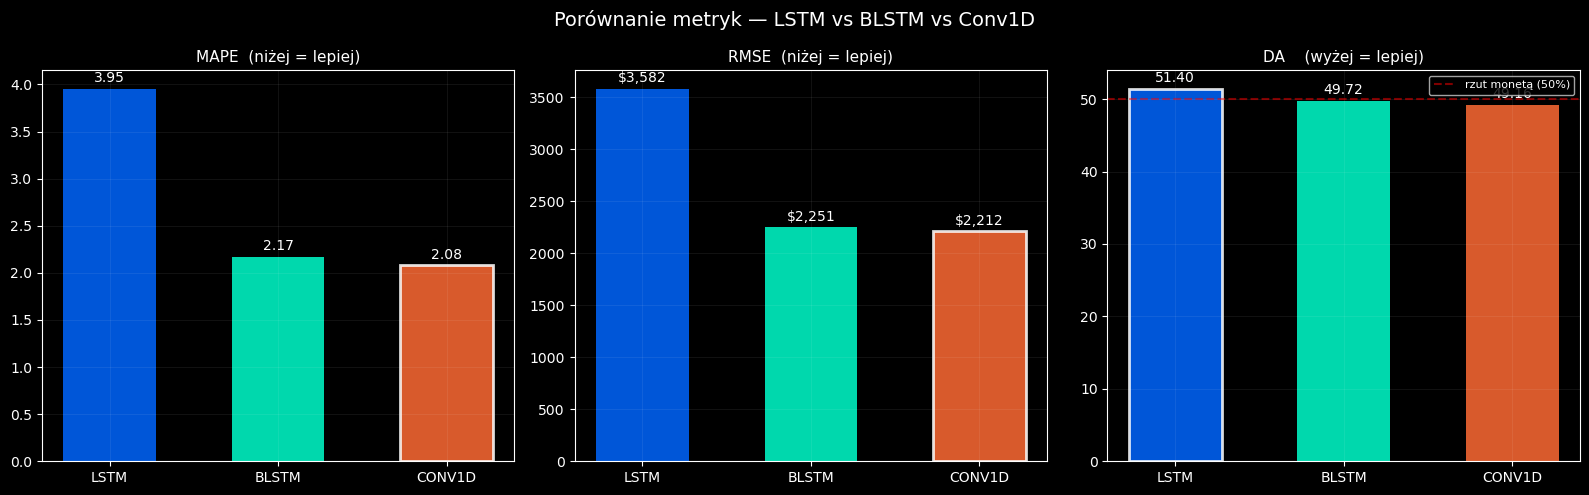

In [3]:
names  = df_metrics.index.tolist()
colors = [C.get(n.lower(), '#888888') for n in names]
x      = np.arange(len(names))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Porównanie metryk — LSTM vs BLSTM vs Conv1D', fontsize=14)

for ax, col, title, lower_better in [
    (axes[0], 'MAPE (%)', 'MAPE  (niżej = lepiej)',  True),
    (axes[1], 'RMSE ($)', 'RMSE  (niżej = lepiej)',  True),
    (axes[2], 'DA (%)',   'DA    (wyżej = lepiej)',   False),
]:
    vals = df_metrics[col].values
    bars = ax.bar(x, vals, color=colors, alpha=0.85, width=0.55)
    best = int(np.argmin(vals) if lower_better else np.argmax(vals))
    bars[best].set_edgecolor('white')
    bars[best].set_linewidth(2)

    for bar, v in zip(bars, vals):
        fmt = f'{v:.2f}' if col != 'RMSE ($)' else f'${v:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                fmt, ha='center', va='bottom', fontsize=10)

    if col == 'DA (%)':
        ax.axhline(50, color='red', linestyle='--', alpha=0.5, label='rzut monetą (50%)')
        ax.legend(fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/metrics_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. Predykcje na zbiorze testowym vs rzeczywistość

[data_loader] Brak kolumn (pomiń lub uzupełnij pipeline): ['mvrv_zscore', 'whale_tx_above_1m']
  [loaded] LSTM  (window=60, features=10, val_loss=0.018909)
  [loaded] BLSTM  (window=14, features=10, val_loss=0.022137)
  [loaded] CONV1D  (window=30, features=10, val_loss=0.017441)


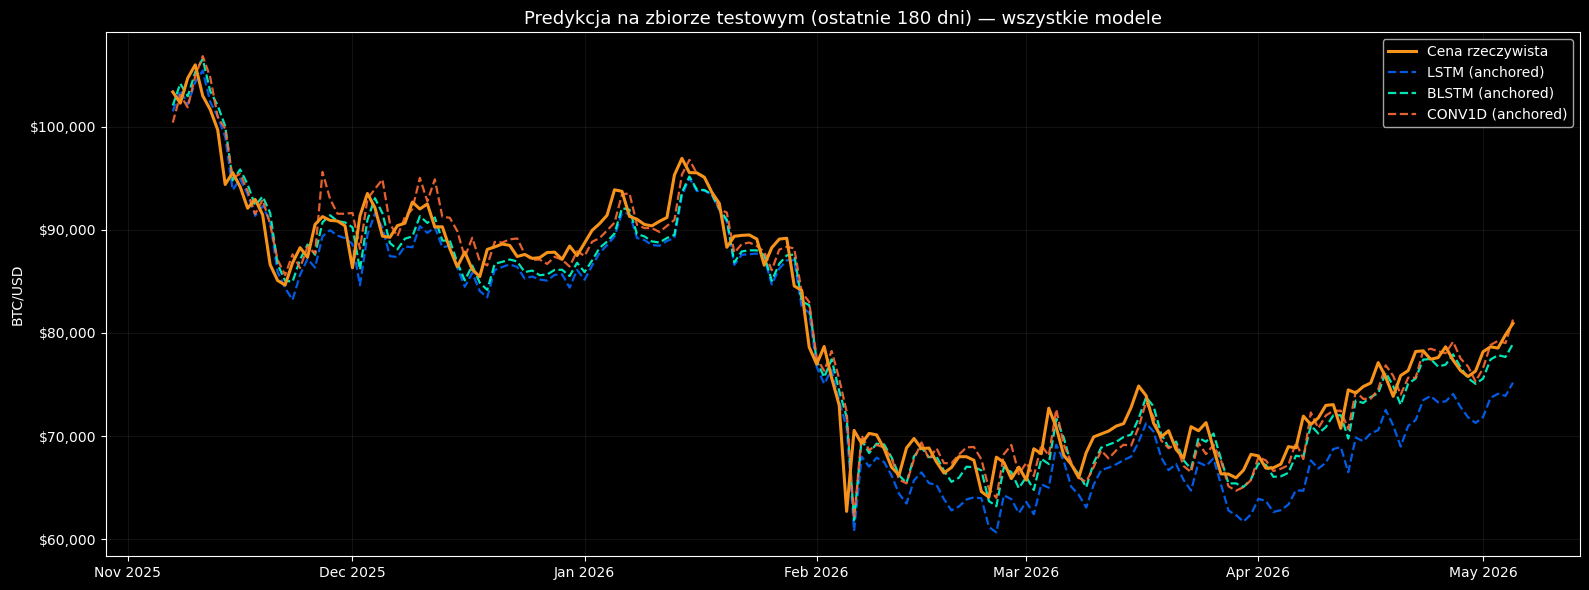

In [4]:
df_full, available = load_full()
TEST_DAYS = 180

fig, ax = plt.subplots(figsize=(16, 6))

real = df_full['price'].iloc[-TEST_DAYS:]
ax.plot(real.index, real.values, color=C['real'], lw=2.2, label='Cena rzeczywista', zorder=10)

for model_name in all_names():
    model = get_model(model_name)
    if not model.is_trained():
        continue
    model.load()

    features = ['price'] + available
    X, y, _, scaler_price, dates = make_sequences(df_full, features, model.window)
    _, X_test, _, y_test, _, dates_test = train_test_split_ts(X, y, dates, TEST_DAYS)

    pred_scaled  = model._keras_model.predict(X_test, verbose=0)
    pred_returns = model._scaler_price.inverse_transform(pred_scaled).flatten()
    real_prev    = df_full['price'].iloc[-len(pred_returns)-1:-1].values
    pred_prices  = pd.Series(
        real_prev * np.exp(pred_returns),
        index=dates_test,
    )

    ax.plot(pred_prices.index, pred_prices.values,
            color=C[model_name], lw=1.6, linestyle='--',
            label=f'{model_name.upper()} (anchored)', alpha=0.9)

ax.set_title('Predykcja na zbiorze testowym (ostatnie 180 dni) — wszystkie modele', fontsize=13)
ax.set_ylabel('BTC/USD')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/test_predictions.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Analiza reszt (residuals)

  [loaded] LSTM  (window=60, features=10, val_loss=0.018909)
  [loaded] BLSTM  (window=14, features=10, val_loss=0.022137)
  [loaded] CONV1D  (window=30, features=10, val_loss=0.017441)


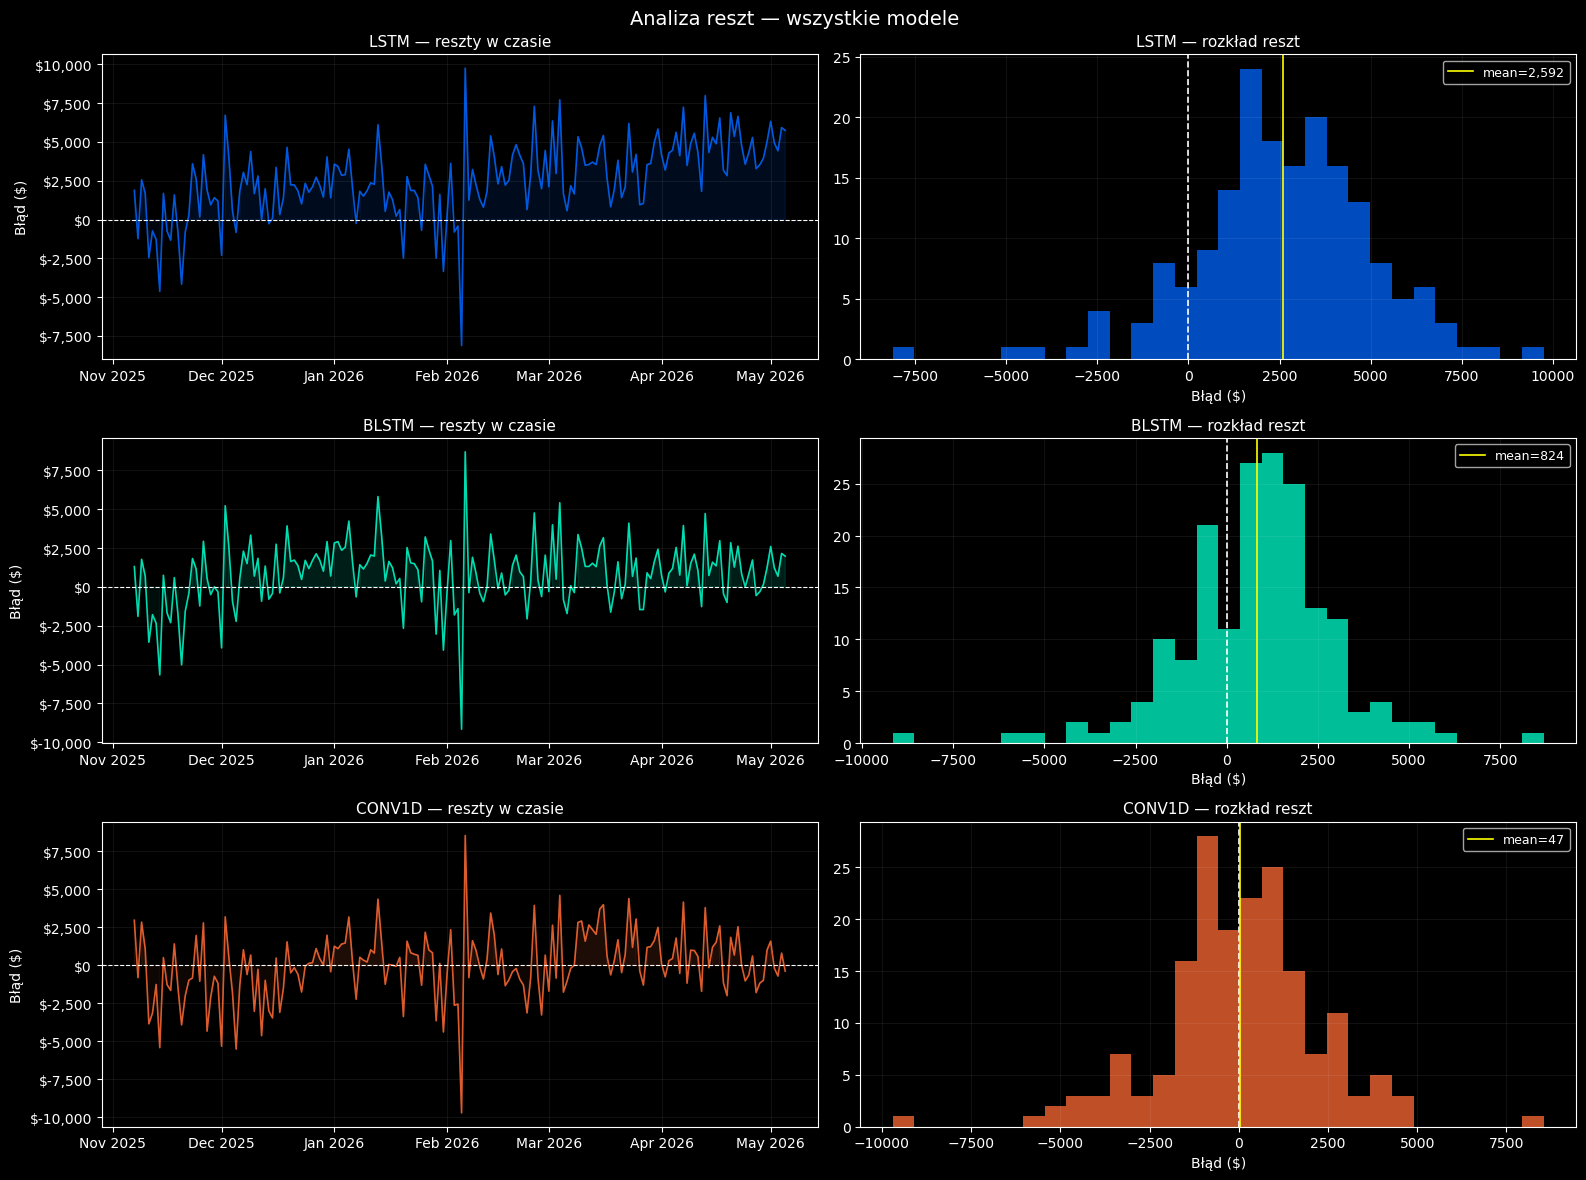

In [5]:
trained_models = [n for n in all_names()
                  if report['models'].get(n, {}).get('status') == 'ok']

fig, axes = plt.subplots(len(trained_models), 2,
                         figsize=(16, 4 * len(trained_models)),
                         squeeze=False)
fig.suptitle('Analiza reszt — wszystkie modele', fontsize=14)

for row, model_name in enumerate(trained_models):
    model = get_model(model_name)
    model.load()

    features = ['price'] + available
    X, y, _, _, dates = make_sequences(df_full, features, model.window)
    _, X_test, _, _, _, dates_test = train_test_split_ts(X, y, dates, TEST_DAYS)

    pred_scaled  = model._keras_model.predict(X_test, verbose=0)
    pred_returns = model._scaler_price.inverse_transform(pred_scaled).flatten()
    real_prev    = df_full['price'].iloc[-len(pred_returns)-1:-1].values
    pred_prices  = real_prev * np.exp(pred_returns)
    true_prices  = df_full['price'].iloc[-len(pred_returns):].values
    residuals    = true_prices - pred_prices

    color = C[model_name]

    # Reszty w czasie
    ax_l = axes[row][0]
    ax_l.plot(dates_test, residuals, color=color, lw=1.2, alpha=0.85)
    ax_l.axhline(0, color='white', lw=0.8, linestyle='--')
    ax_l.fill_between(dates_test, residuals, 0,
                      where=(residuals > 0), color=color, alpha=0.12)
    ax_l.fill_between(dates_test, residuals, 0,
                      where=(residuals < 0), color=color, alpha=0.06)
    ax_l.set_title(f'{model_name.upper()} — reszty w czasie', fontsize=11)
    ax_l.set_ylabel('Błąd ($)')
    ax_l.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax_l.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    # Histogram reszt
    ax_r = axes[row][1]
    ax_r.hist(residuals, bins=30, color=color, alpha=0.75, edgecolor='none')
    ax_r.axvline(0,               color='white', lw=1.2, linestyle='--')
    ax_r.axvline(np.mean(residuals), color='yellow', lw=1.2,
                 linestyle='-', label=f'mean={np.mean(residuals):,.0f}')
    ax_r.set_title(f'{model_name.upper()} — rozkład reszt', fontsize=11)
    ax_r.set_xlabel('Błąd ($)')
    ax_r.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/residuals_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Prognoza przyszłości — wszystkie modele na 4 horyzontach

  [loaded] LSTM  (window=60, features=10, val_loss=0.018909)
[data_loader] Brak kolumn (pomiń lub uzupełnij pipeline): ['mvrv_zscore', 'whale_tx_above_1m']
  [loaded] BLSTM  (window=14, features=10, val_loss=0.022137)
[data_loader] Brak kolumn (pomiń lub uzupełnij pipeline): ['mvrv_zscore', 'whale_tx_above_1m']
  [loaded] CONV1D  (window=30, features=10, val_loss=0.017441)
[data_loader] Brak kolumn (pomiń lub uzupełnij pipeline): ['mvrv_zscore', 'whale_tx_above_1m']


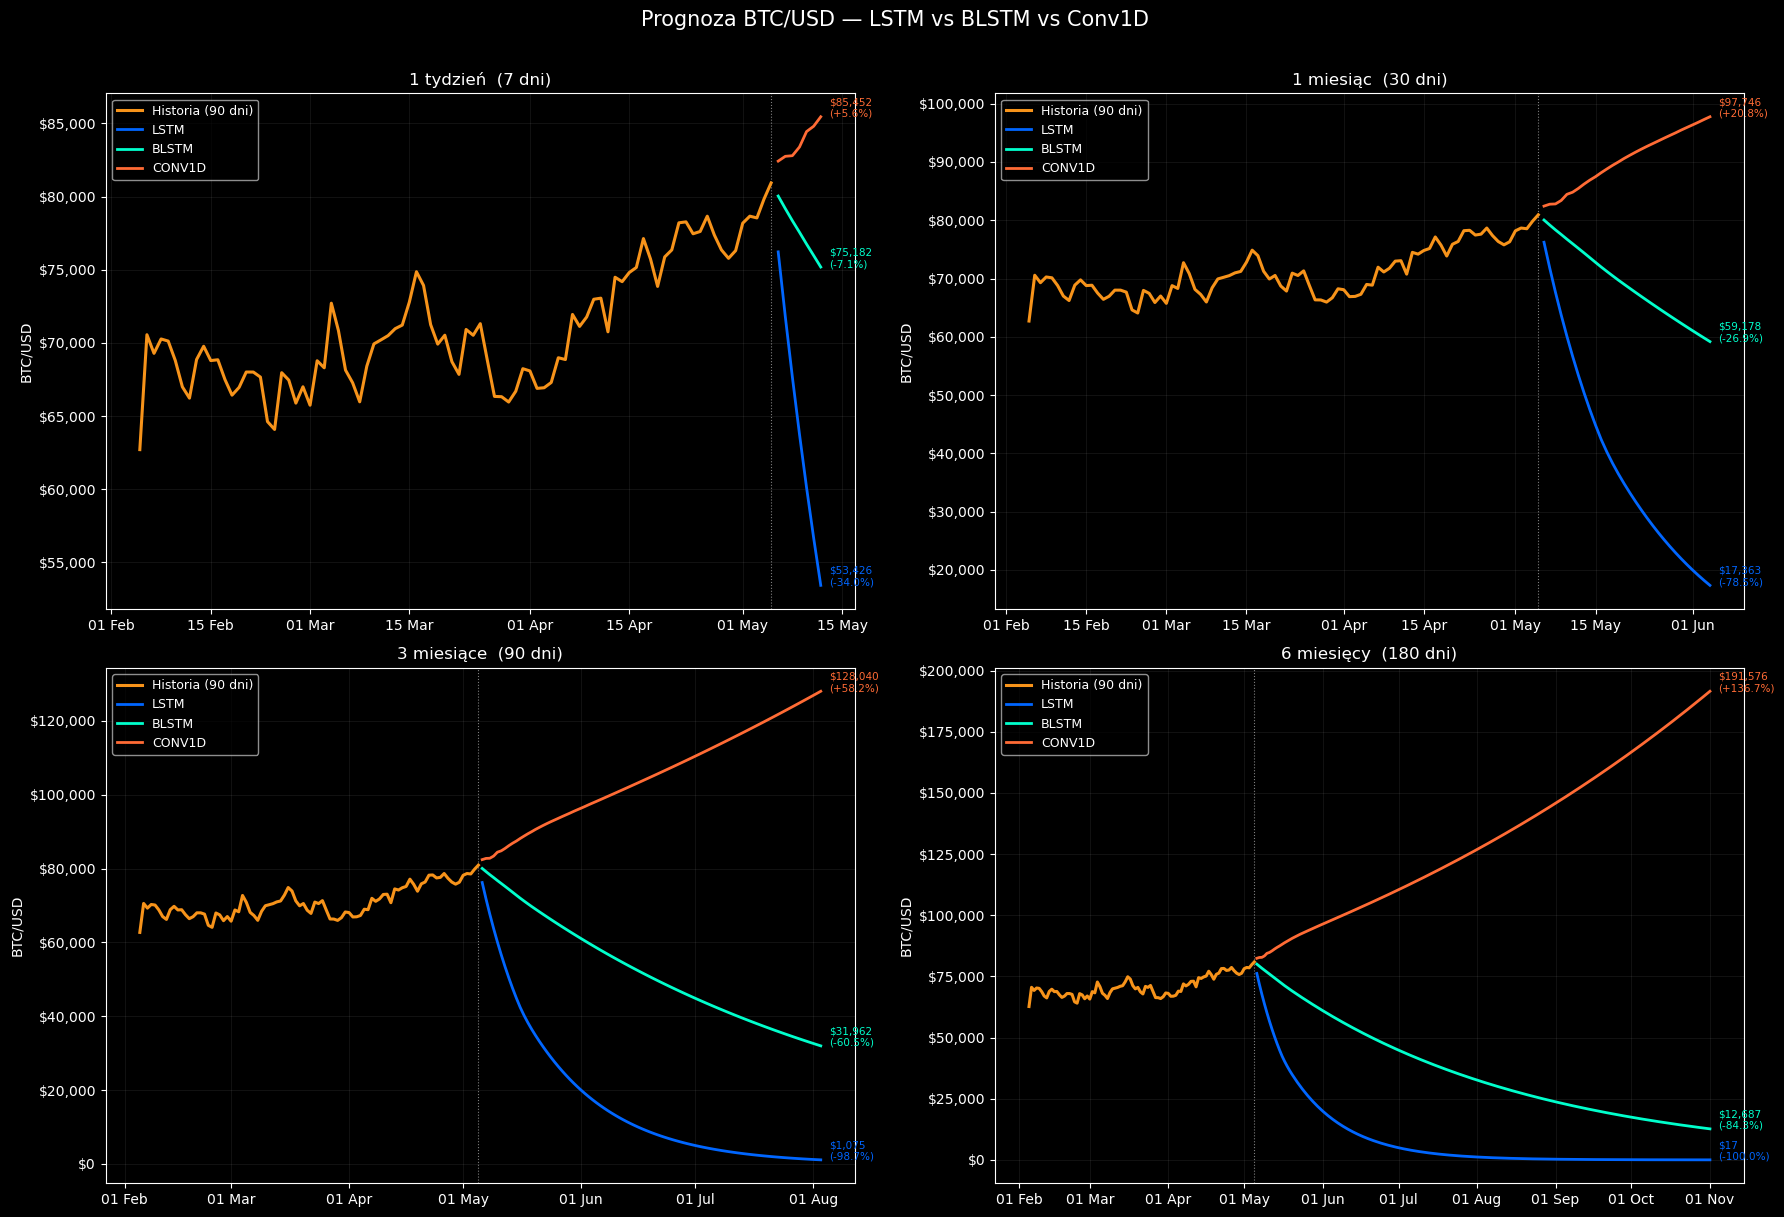

In [6]:
HORIZONS_PLOT = {'1 tydzień': 7, '1 miesiąc': 30, '3 miesiące': 90, '6 miesięcy': 180}
MAX_STEPS     = 180

# Wygeneruj prognozy raz dla wszystkich modeli
forecasts = {}
for model_name in trained_models:
    try:
        forecasts[model_name.upper()] = predict_one(model_name, MAX_STEPS)
    except Exception as e:
        print(f'{model_name}: {e}')

last_price = df_full['price'].iloc[-1]
last_date  = df_full.index[-1]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Prognoza BTC/USD — LSTM vs BLSTM vs Conv1D', fontsize=15, y=1.01)

for ax, (h_name, h_days) in zip(axes.flatten(), HORIZONS_PLOT.items()):
    hist = df_full['price'].iloc[-90:]
    ax.plot(hist.index, hist.values, color=C['real'], lw=2.2,
            label='Historia (90 dni)', zorder=10)
    ax.axvline(last_date, color='white', lw=0.8, linestyle=':', alpha=0.5)

    for label, series in forecasts.items():
        sliced = series.iloc[:h_days]
        color  = C.get(label.lower(), '#888888')
        ax.plot(sliced.index, sliced.values,
                color=color, lw=2.0, label=label)

        val  = sliced.iloc[-1]
        chg  = (val / last_price - 1) * 100
        sign = '+' if chg >= 0 else ''
        ax.annotate(
            f'${val:,.0f}\n({sign}{chg:.1f}%)',
            xy=(sliced.index[-1], val),
            xytext=(6, 0), textcoords='offset points',
            fontsize=7.5, color=color,
        )

    ax.set_title(f'{h_name}  ({h_days} dni)', fontsize=12)
    ax.set_ylabel('BTC/USD')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.legend(fontsize=9, loc='upper left', framealpha=0.7)

plt.tight_layout()
plt.savefig('../data/processed/forecast_all_models.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Dryft prognoz vs ostatnia znana cena

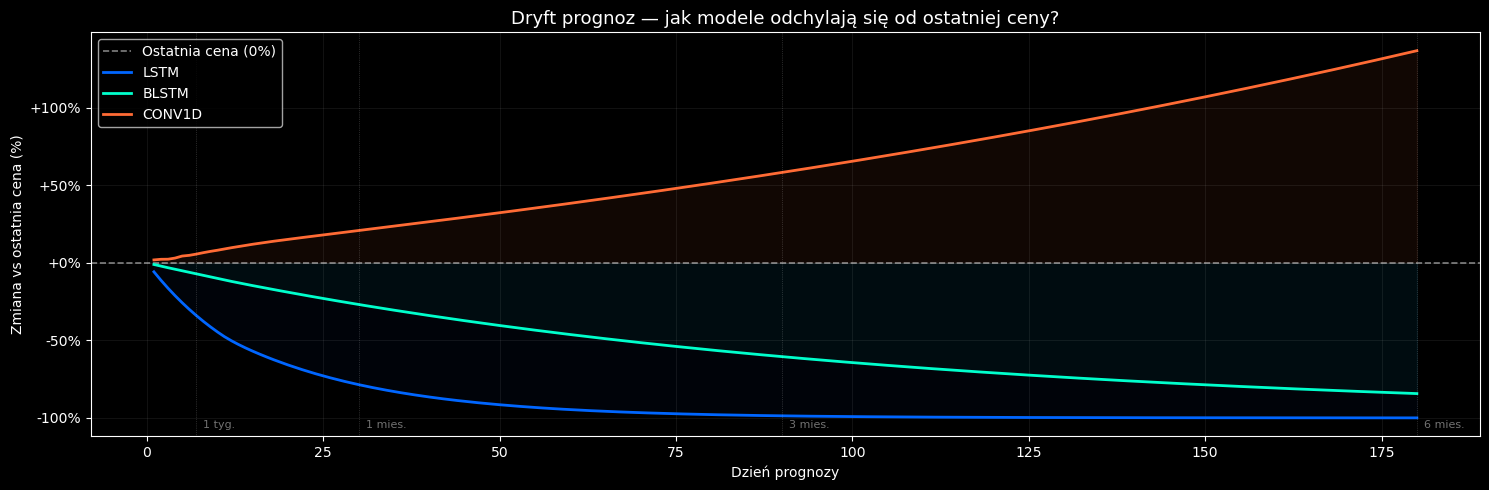

In [7]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.axhline(0, color='white', lw=1.2, linestyle='--', alpha=0.5, label='Ostatnia cena (0%)')

days_axis = np.arange(1, MAX_STEPS + 1)
for label, series in forecasts.items():
    drift = (series.values / last_price - 1) * 100
    color = C.get(label.lower(), '#888888')
    ax.plot(days_axis, drift, color=color, lw=2.0, label=label)
    ax.fill_between(days_axis, drift, 0,
                    where=(drift > 0), color=color, alpha=0.07)
    ax.fill_between(days_axis, drift, 0,
                    where=(drift < 0), color=color, alpha=0.04)

for h_days, h_name in [(7,'1 tyg.'), (30,'1 mies.'), (90,'3 mies.'), (180,'6 mies.')]:
    ax.axvline(h_days, color='white', lw=0.5, linestyle=':', alpha=0.3)
    ax.text(h_days+1, ax.get_ylim()[0] * 0.95, h_name,
            fontsize=8, color='white', alpha=0.45)

ax.set_xlabel('Dzień prognozy')
ax.set_ylabel('Zmiana vs ostatnia cena (%)')
ax.set_title('Dryft prognoz — jak modele odchylają się od ostatniej ceny?', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/forecast_drift.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Tabela prognoz punktowych

In [8]:
print(f'Ostatnia cena: ${last_price:,.0f}  ({last_date.date()})')
print()

header = f"{'Horyzont':<16} {'Dni':>4}  {'Data':^12}"
for label in forecasts:
    header += f"  {label:>16}"
print(header)
print('─' * len(header))

for h_name, h_days in HORIZONS_PLOT.items():
    d   = (last_date + pd.Timedelta(days=h_days)).date()
    row = f'  {h_name:<14} {h_days:>4}  {str(d):^12}'
    for series in forecasts.values():
        val  = series.iloc[h_days - 1]
        chg  = (val / last_price - 1) * 100
        sign = '+' if chg >= 0 else ''
        row += f'  ${val:>8,.0f} ({sign}{chg:.1f}%)'
    print(row)

Ostatnia cena: $80,927  (2026-05-05)

Horyzont          Dni      Data                  LSTM             BLSTM            CONV1D
─────────────────────────────────────────────────────────────────────────────────────────
  1 tydzień         7   2026-05-12   $  53,426 (-34.0%)  $  75,182 (-7.1%)  $  85,452 (+5.6%)
  1 miesiąc        30   2026-06-04   $  17,363 (-78.5%)  $  59,178 (-26.9%)  $  97,746 (+20.8%)
  3 miesiące       90   2026-08-03   $   1,075 (-98.7%)  $  31,962 (-60.5%)  $ 128,040 (+58.2%)
  6 miesięcy      180   2026-11-01   $      17 (-100.0%)  $  12,687 (-84.3%)  $ 191,576 (+136.7%)
